# Fundamentos de *Deep Learning I* 
> Héctor J. Hortúa, PhD · Instituto de Neurociencias
## Carga de datos en **TensorFlow**: la API `tf.data`

>  **Módulo 2 — Herramientas y manejo de datos**
> **Framework:** TensorFlow 2 / Keras

Una red se entrena con **batch** de datos que se le entregan uno tras otro. Construir el flujo: leer, transformar, barajar, agrupar y hacerlo con eficiencia es el trabajo de un **pipeline de datos**. En TensorFlow ese pipeline se expresa con la API **`tf.data.Dataset`**.

### Objetivos

1. Crear datasets desde memoria (`from_tensors`, `from_tensor_slices`), texto y CSV.
2. Encadenar transformaciones: `map`, `shuffle`, `batch`, `cache`, `prefetch`.
3. Descargar datos listos con **TensorFlow Datasets** (`tfds`).
4. Aplicar **data augmentation** de tres maneras distintas.
5. Montar un pipeline de **texto** con `TextVectorization` y *embeddings*.

## La API `tf.data.Dataset`

`tf.data.Dataset` (`pip install tensorflow_datasets`) permite escribir pipelines **descriptivos y eficientes**. Trabajar con un dataset sigue pasos:

1. **Crear** un dataset a partir de tus datos de entrada.
2. **Transformarlo** encadenando operaciones de preprocesamiento (`map`, `batch`, `shuffle`, …).
3. **Iterar** sobre él y procesar los elementos.

La iteración ocurre en modo **streaming**, así que no es necesario que todo el conjunto quepa en memoria: los elementos se producen bajo demanda.

### Crear un dataset desde memoria

Para construir un dataset a partir de datos que ya están en memoria tienes principalmente:

- **`tf.data.Dataset.from_tensor_slices()`** — **corta** el tensor por su primera dimensión: cada *slice* es un elemento. Un tensor `(7, 10)` produce **7 elementos** de forma `(10,)`. Es lo que usarás casi siempre.
- **`tf.data.Dataset.from_tensors()`** — mete **todo el tensor como un único elemento**. Un `(7, 10)` produce **1 elemento** de forma `(7, 10)`.
- **`tf.data.TFRecordDataset()`** — para leer el formato binario eficiente de TensorFlow (TFRecord).

La diferencia entre las dos primeras es sutil pero crucial; los ejemplos siguientes la hacen evidente.

### Desde un arreglo NumPy o una lista de Python

`tf.data` acepta indistintamente arreglos NumPy o listas de Python. Partimos de un arreglo `(7, 10)` para ver cómo lo interpretan `from_tensor_slices` (7 filas → 7 elementos) frente a `from_tensors` (1 elemento).

In [1]:
import tensorflow_datasets as tfds
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
print(tf.__version__)

2.21.0


In [2]:
array_examp =np.array(range(70)).reshape(7,10)
lista_examp = array_examp.tolist()
print(array_examp.shape)

(7, 10)


In [3]:
dataset1 = tf.data.Dataset.from_tensor_slices(array_examp)
dataset2 = tf.data.Dataset.from_tensors(array_examp)
dataset_lista_1 = tf.data.Dataset.from_tensor_slices(lista_examp)
dataset_lista_2 = tf.data.Dataset.from_tensors(lista_examp)

`element_spec` describe la **forma y tipo** de cada elemento sin iterar. Compara: `dataset1` (hecho con `from_tensor_slices`) tiene elementos `(10,)` —cortó las 7 filas—, mientras `dataset2` (con `from_tensors`) tiene un único elemento `(7, 10)`. Esa es la diferencia práctica entre ambas funciones.

In [4]:
print(dataset1.element_spec)
print(dataset2.element_spec)
print(dataset_lista_1.element_spec)
print(dataset_lista_2.element_spec)

TensorSpec(shape=(10,), dtype=tf.int64, name=None)
TensorSpec(shape=(7, 10), dtype=tf.int64, name=None)
TensorSpec(shape=(10,), dtype=tf.int32, name=None)
TensorSpec(shape=(7, 10), dtype=tf.int32, name=None)


### Datasets con tuplas `(features, label)`

Lo normal es que cada elemento sea una tupla entrada/etiqueta. Al usar `from_tensor_slices((a, b))`, **la primera dimensión de `a` y `b` debe coincidir** (es la que se corta en elementos). Abajo, `tensor1` y `tensor2` tienen 10 en la primera dimensión (compatibles); `tensor3` tiene 9 (incompatible: al intentar cortar dará error).

In [5]:
tensor1 = tf.ones([10,2,2])
tensor2 = tf.ones([10,1])
tensor3 = tf.ones([9,2,2])

In [6]:
dataset3 = tf.data.Dataset.from_tensor_slices((tensor1, tensor2))

In [7]:
dataset4 = tf.data.Dataset.from_tensor_slices((tensor1, tensor3))

ValueError: Dimensions 10 and 9 are not compatible

In [8]:
dataset5 = tf.data.Dataset.from_tensors((tensor1, tensor2))
dataset6 = tf.data.Dataset.from_tensors((tensor1, tensor3))

In [9]:
print(dataset3.element_spec)
print(dataset5.element_spec)
print(dataset6.element_spec)

(TensorSpec(shape=(2, 2), dtype=tf.float32, name=None), TensorSpec(shape=(1,), dtype=tf.float32, name=None))
(TensorSpec(shape=(10, 2, 2), dtype=tf.float32, name=None), TensorSpec(shape=(10, 1), dtype=tf.float32, name=None))
(TensorSpec(shape=(10, 2, 2), dtype=tf.float32, name=None), TensorSpec(shape=(9, 2, 2), dtype=tf.float32, name=None))


`zip` combina varios datasets emparejando sus elementos, igual que el `zip` de Python. Sirve para unir features y labels que vienen de datasets separados.

In [10]:
dataset3 = tf.data.Dataset.zip((dataset1, dataset2))
print(dataset3.element_spec)
for a, b in dataset3:
      print('shapes: {a.shape}, {b.shape}'.format(a=a, b=b))


(TensorSpec(shape=(10,), dtype=tf.int64, name=None), TensorSpec(shape=(7, 10), dtype=tf.int64, name=None))
shapes: (10,), (7, 10)


### Iteración

Un `Dataset` es iterable: puedes recorrerlo con un `for`. Cada elemento es un tensor (o una tupla de tensores). Con `.numpy()` obtienes su valor como arreglo NumPy.

In [11]:
for elem in dataset1:
  print(elem.numpy())

[0 1 2 3 4 5 6 7 8 9]
[10 11 12 13 14 15 16 17 18 19]
[20 21 22 23 24 25 26 27 28 29]
[30 31 32 33 34 35 36 37 38 39]
[40 41 42 43 44 45 46 47 48 49]
[50 51 52 53 54 55 56 57 58 59]
[60 61 62 63 64 65 66 67 68 69]


### Enumerar

`enumerate` empareja cada elemento con un índice incremental, como el `enumerate` de Python pero dentro del pipeline.

In [12]:
dataset_enu = dataset1.enumerate(start=5)
for element in dataset_enu.as_numpy_iterator():
  print(element)

(np.int64(5), array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))
(np.int64(6), array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19]))
(np.int64(7), array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29]))
(np.int64(8), array([30, 31, 32, 33, 34, 35, 36, 37, 38, 39]))
(np.int64(9), array([40, 41, 42, 43, 44, 45, 46, 47, 48, 49]))
(np.int64(10), array([50, 51, 52, 53, 54, 55, 56, 57, 58, 59]))
(np.int64(11), array([60, 61, 62, 63, 64, 65, 66, 67, 68, 69]))


### Barajar (`shuffle`) y repetir (`repeat`)

`shuffle(buffer)` mezcla los elementos usando un búfer de mezcla: cuanto mayor el búfer, mejor la aleatorización (pasar `len(dataset)` baraja perfectamente). `reshuffle_each_iteration=True` reordena en cada pasada. `repeat(count)` repite el dataset `count` veces (`-1` = infinito), lo que da varias **épocas** de entrenamiento.

> **Orden importa:** `shuffle` **antes** de `batch` baraja muestras individuales; al revés, barajarías lotes ya formados.

In [13]:
dataset_shu = dataset1.shuffle(len(dataset1), reshuffle_each_iteration=True)
dataset_shu=dataset_shu.repeat(count=4) ## si count =-1 => se repite indefinidamente 
for element in dataset_shu.as_numpy_iterator():
  print(element)

[50 51 52 53 54 55 56 57 58 59]
[60 61 62 63 64 65 66 67 68 69]
[0 1 2 3 4 5 6 7 8 9]
[40 41 42 43 44 45 46 47 48 49]
[10 11 12 13 14 15 16 17 18 19]
[30 31 32 33 34 35 36 37 38 39]
[20 21 22 23 24 25 26 27 28 29]
[30 31 32 33 34 35 36 37 38 39]
[10 11 12 13 14 15 16 17 18 19]
[0 1 2 3 4 5 6 7 8 9]
[20 21 22 23 24 25 26 27 28 29]
[40 41 42 43 44 45 46 47 48 49]
[50 51 52 53 54 55 56 57 58 59]
[60 61 62 63 64 65 66 67 68 69]
[0 1 2 3 4 5 6 7 8 9]
[50 51 52 53 54 55 56 57 58 59]
[30 31 32 33 34 35 36 37 38 39]
[20 21 22 23 24 25 26 27 28 29]
[40 41 42 43 44 45 46 47 48 49]
[60 61 62 63 64 65 66 67 68 69]
[10 11 12 13 14 15 16 17 18 19]
[60 61 62 63 64 65 66 67 68 69]
[40 41 42 43 44 45 46 47 48 49]
[50 51 52 53 54 55 56 57 58 59]
[20 21 22 23 24 25 26 27 28 29]
[0 1 2 3 4 5 6 7 8 9]
[10 11 12 13 14 15 16 17 18 19]
[30 31 32 33 34 35 36 37 38 39]


### Agrupar en lotes (`batch`)

`batch(n)` agrupa `n` elementos consecutivos en un solo tensor con una nueva dimensión de lote al frente. `drop_remainder=True` descarta el último lote si queda incompleto (útil cuando el modelo exige un tamaño de lote fijo). `take(k)` toma solo los primeros `k` elementos, práctico para inspeccionar.

In [14]:
dataset_range = tf.data.Dataset.range(20) #[0,1,2,...19]
dataset_range = dataset_range.batch(3)
dataset_range = dataset_range.enumerate(start=0)
for element in dataset_range.as_numpy_iterator():
  print(element)

(np.int64(0), array([0, 1, 2]))
(np.int64(1), array([3, 4, 5]))
(np.int64(2), array([6, 7, 8]))
(np.int64(3), array([ 9, 10, 11]))
(np.int64(4), array([12, 13, 14]))
(np.int64(5), array([15, 16, 17]))
(np.int64(6), array([18, 19]))


In [15]:
dataset_range = tf.data.Dataset.range(20) #[0,1,2,...19]
dataset_range = dataset_range.batch(3,drop_remainder=True)
dataset_range = dataset_range.enumerate(start=0)
for element in dataset_range.as_numpy_iterator():
  print(element)

(np.int64(0), array([0, 1, 2]))
(np.int64(1), array([3, 4, 5]))
(np.int64(2), array([6, 7, 8]))
(np.int64(3), array([ 9, 10, 11]))
(np.int64(4), array([12, 13, 14]))
(np.int64(5), array([15, 16, 17]))


In [16]:
for element in dataset_range.take(2):   ##Take()
  print(element[0].numpy(),element[1].numpy())

0 [0 1 2]
1 [3 4 5]


In [17]:
dataset1_range = dataset1.batch(3)
dataset1_range = dataset1_range.enumerate(start=0)
for element in dataset1_range.as_numpy_iterator():
  print(element)

(np.int64(0), array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24, 25, 26, 27, 28, 29]]))
(np.int64(1), array([[30, 31, 32, 33, 34, 35, 36, 37, 38, 39],
       [40, 41, 42, 43, 44, 45, 46, 47, 48, 49],
       [50, 51, 52, 53, 54, 55, 56, 57, 58, 59]]))
(np.int64(2), array([[60, 61, 62, 63, 64, 65, 66, 67, 68, 69]]))


In [18]:
dataset1_range = dataset1.batch(1)
dataset1_range = dataset1_range.enumerate(start=0)
for element in dataset1_range.as_numpy_iterator():
  print(element)

(np.int64(0), array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]]))
(np.int64(1), array([[10, 11, 12, 13, 14, 15, 16, 17, 18, 19]]))
(np.int64(2), array([[20, 21, 22, 23, 24, 25, 26, 27, 28, 29]]))
(np.int64(3), array([[30, 31, 32, 33, 34, 35, 36, 37, 38, 39]]))
(np.int64(4), array([[40, 41, 42, 43, 44, 45, 46, 47, 48, 49]]))
(np.int64(5), array([[50, 51, 52, 53, 54, 55, 56, 57, 58, 59]]))
(np.int64(6), array([[60, 61, 62, 63, 64, 65, 66, 67, 68, 69]]))


### Transformar con `map`

`map(f)` aplica la función `f` a **cada elemento** del dataset, de forma perezosa. Es la operación central del preprocesamiento: normalizar, redimensionar, tokenizar, separar features/label, etc. Aquí `dense_1_step` convierte cada secuencia en un par (entrada, objetivo) desplazado una posición —el patrón típico para predecir el siguiente valor de una serie.

In [19]:
def dense_1_step(batch):
  return batch[:-1], batch[1:]

In [20]:
predict_dense_1_step =dataset1.map(dense_1_step)

for features, label in predict_dense_1_step:
  print(features.numpy(), " => ", label.numpy())

[0 1 2 3 4 5 6 7 8]  =>  [1 2 3 4 5 6 7 8 9]
[10 11 12 13 14 15 16 17 18]  =>  [11 12 13 14 15 16 17 18 19]
[20 21 22 23 24 25 26 27 28]  =>  [21 22 23 24 25 26 27 28 29]
[30 31 32 33 34 35 36 37 38]  =>  [31 32 33 34 35 36 37 38 39]
[40 41 42 43 44 45 46 47 48]  =>  [41 42 43 44 45 46 47 48 49]
[50 51 52 53 54 55 56 57 58]  =>  [51 52 53 54 55 56 57 58 59]
[60 61 62 63 64 65 66 67 68]  =>  [61 62 63 64 65 66 67 68 69]


### Aplanar con `flat_map`

`flat_map` aplica una función que devuelve **otro dataset** por cada elemento, y luego **concatena** todos los resultados en un único dataset plano. Se usa, por ejemplo, para expandir cada fila en varios elementos.

In [21]:
dataset = dataset1.flat_map(
    lambda x: tf.data.Dataset.from_tensor_slices(x))
list(dataset.as_numpy_iterator())

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(59),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65),
 np.int64(66),
 np.i

### Leer datasets de texto (`.txt`)

`tf.data.TextLineDataset` crea un dataset donde **cada elemento es una línea** de uno o varios archivos de texto. `Dataset.list_files` construye un dataset con los **nombres de archivo** que coincidan con un patrón (útil para leer muchos ficheros).

> Estas celdas requieren los archivos `sonnets.txt` (y similares) en el directorio de trabajo.

In [22]:
with open('sonnets.txt', 'r', encoding='utf-8') as file:
    text_string = file.read().replace('\n', ' ')
text_string[:50]

'FROM fairest creatures we desire increase, That th'

In [23]:
dataset_text = tf.data.TextLineDataset(["sonnets.txt", "sonnets_2.txt"])
dataset_text

<TextLineDatasetV2 element_spec=TensorSpec(shape=(), dtype=tf.string, name=None)>

In [24]:
dataset_text_set = tf.data.Dataset.list_files("./*.txt")
dataset_text_set

<_ShuffleDataset element_spec=TensorSpec(shape=(), dtype=tf.string, name=None)>

### Leer datasets tabulares (`.csv`)

Tres caminos habituales para CSV: cargarlo con **pandas** y pasarlo a `from_tensor_slices` (cómodo si cabe en memoria), o usar **`tf.data.experimental.make_csv_dataset`**, que lee por lotes directamente del archivo y permite indicar la **columna de etiqueta**. La función `extract_time` muestra cómo aplicar lógica Python (parsear fechas) dentro del pipeline con `tf.py_function`.

> Estas celdas requieren el archivo `Sunspots.csv`.

In [25]:
pandas_dataframe = pd.read_csv('Sunspots.csv')
pandas_dataframe.head()

,Unnamed: 0,Date,Monthly Mean Total Sunspot Number
0,0,1749-01-31,96.7
1,1,1749-02-28,104.3
2,2,1749-03-31,116.7
3,3,1749-04-30,92.8
4,4,1749-05-31,141.7


In [26]:
dataframe_dict = dict(pandas_dataframe)
print(dataframe_dict.keys())
print("tamano del dataframe: ",len(pandas_dataframe))

dict_keys(['Unnamed: 0', 'Date', 'Monthly Mean Total Sunspot Number'])
tamano del dataframe:  3235


In [27]:
pandas_dataset = tf.data.Dataset.from_tensor_slices(dataframe_dict)
pandas_dataset.element_spec
print(pandas_dataset.cardinality().numpy())

3235


In [28]:
csv_dataset = tf.data.experimental.make_csv_dataset(r'C:\Users\javier\Documents\deep_learning_2026_phd\deep-learning-i\clase1\sunspots.csv',
                                                    batch_size=1,
                                                    label_name='Monthly Mean Total Sunspot Number')
csv_dataset.element_spec

(OrderedDict([('', TensorSpec(shape=(1,), dtype=tf.int32, name=None)),
              ('Date', TensorSpec(shape=(1,), dtype=tf.string, name=None))]),
 TensorSpec(shape=(1,), dtype=tf.float32, name=None))

In [29]:
def extract_time(x,label):
    date_ = datetime.fromisoformat(x.numpy()[0].decode("utf-8"))
    year =date_.year
    month =date_.month
    day =date_.day
    return day, year, month, label


data_map=csv_dataset.map(lambda x,z: tf.py_function(extract_time, [x['Date'],z], [tf.int32,tf.int32,tf.int32,tf.float32])).take(5)

In [30]:
for df in data_map:
    day, year, month,label = df
    print(day.numpy(),year.numpy(),month.numpy(),label.numpy())

31 1998 12 [119.2]
31 1767 10 [73.5]
30 1972 11 [59.2]
30 1827 4 [76.7]
31 1775 10 [9.3]


## TensorFlow Datasets (`tfds`)

`tfds` da acceso a **decenas de datasets listos** (imágenes, texto, audio…) ya divididos en train/test. Con `as_supervised=True` cada elemento llega como tupla `(imagen, etiqueta)`, y `with_info=True` devuelve metadatos (número de clases, tamaños, etc.).

Catálogo completo: <https://www.tensorflow.org/datasets/catalog/overview>

> La primera vez, `tfds.load` **descarga** el dataset (aquí, MNIST).

In [31]:
(ds_train, ds_test), ds_info = tfds.load(
    name = 'mnist',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True)

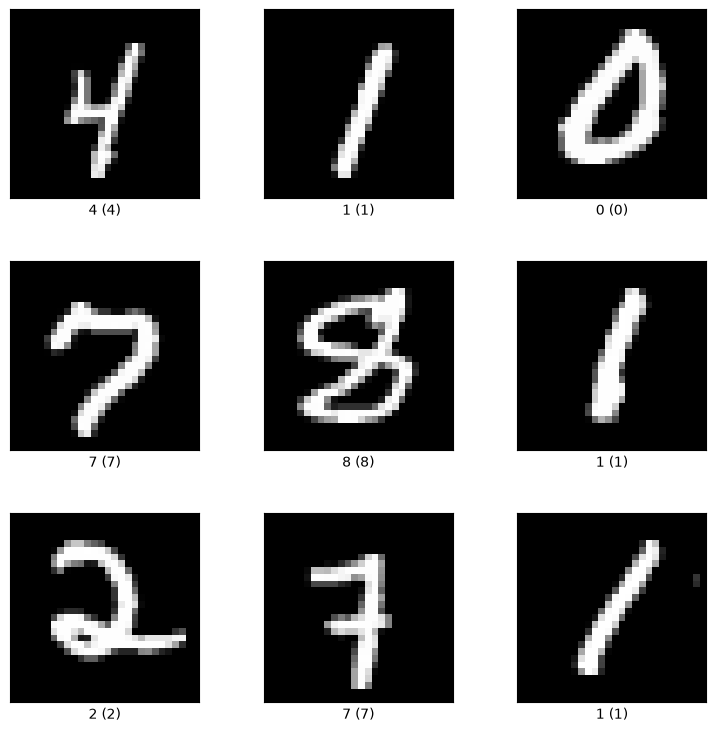

In [32]:
fig = tfds.show_examples(ds_train, ds_info)

### Un pipeline de entrenamiento completo

La función `data_load` encadena las operaciones en el **orden recomendado** por TensorFlow para máximo rendimiento:

- **`map(..., num_parallel_calls=AUTOTUNE)`** — preprocesa en paralelo (aquí normaliza a [0,1] y hace *one-hot* de la etiqueta).
- **`cache()`** — guarda en memoria el resultado tras la primera época (evita repetir el trabajo).
- **`shuffle(len)`** — baraja las muestras.
- **`batch(n)`** — agrupa en lotes.
- **`prefetch(AUTOTUNE)`** — prepara el siguiente lote mientras la GPU procesa el actual, solapando cómputo y carga.

`AUTOTUNE` deja que TensorFlow ajuste solo el nivel de paralelismo. Este patrón `map → cache → shuffle → batch → prefetch` es la plantilla que reutilizarás en casi todos tus pipelines de imagen.

In [33]:
def normalize_img(image,label ):
  return tf.cast(image, tf.float32) / 255., tf.one_hot(label,depth=10)


def data_load(data_ds,augmented=normalize_img,shuffle_=True ,batch_=5):
    data_ds = data_ds.map(
        augmented, num_parallel_calls=tf.data.AUTOTUNE)
    data_ds = data_ds.cache()
    if shuffle_:
        data_ds = data_ds.shuffle(len(data_ds))
    data_ds = data_ds.batch(batch_)
    data_ds = data_ds.prefetch(tf.data.AUTOTUNE)
    return data_ds

In [34]:
data_train = data_load(ds_train)
data_test = data_load(ds_test,shuffle_=False)

(5, 28, 28, 1) tf.Tensor(
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]], shape=(5, 10), dtype=float32)
(5, 28, 28, 1) tf.Tensor(
[[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]], shape=(5, 10), dtype=float32)
(5, 28, 28, 1) tf.Tensor(
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]], shape=(5, 10), dtype=float32)
(5, 28, 28, 1) tf.Tensor(
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]], shape=(5, 10), dtype=float32)


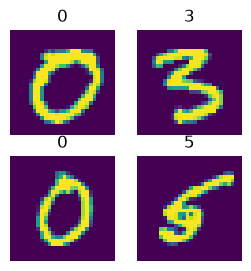

In [35]:
plt.figure(figsize=(3, 3))
i=0
for ds,lb in data_train.take(4):
    print(ds.shape,lb)
    ax = plt.subplot(2, 2, i + 1)
    plt.imshow(ds[0].numpy())
    index = tf.argmax(lb, axis=1)
    plt.title('{}'.format(index[0].numpy()))
    plt.axis("off")
    i+=1

## Data Augmentation

El *data augmentation* genera variaciones de las imágenes (volteos, giros, recortes, cambios de contraste) **al vuelo**, multiplicando la variedad de datos sin ocupar más disco. Es una de las mejores defensas contra el *overfitting* (Módulo 4) y se aplica **solo al conjunto de entrenamiento**.

Veremos **tres formas** de hacerlo en TensorFlow. Guía oficial: <https://www.tensorflow.org/guide/keras/preprocessing_layers>

### Método 1 — Funciones `tf.image` dentro de `map`

La forma más directa: una función que usa operaciones de `tf.image` (`random_flip_left_right`, `rot90`, …) y se aplica con `map`. El aumento vive **en el pipeline de datos**, no en el modelo.

In [36]:
def augment_data(images, labels):
    images = tf.image.random_flip_left_right(images)
    images = tf.image.random_flip_up_down(images)
    images = tf.image.rot90(images)
    return images, labels

In [37]:
data_train = data_load(ds_train,augmented=augment_data)
data_test = data_load(ds_test,augmented=augment_data,shuffle_=False)

(5, 28, 28, 1) tf.Tensor([9 1 1 8 7], shape=(5,), dtype=int64)
(5, 28, 28, 1) tf.Tensor([8 4 5 0 6], shape=(5,), dtype=int64)
(5, 28, 28, 1) tf.Tensor([4 0 3 9 7], shape=(5,), dtype=int64)
(5, 28, 28, 1) tf.Tensor([6 3 6 6 1], shape=(5,), dtype=int64)


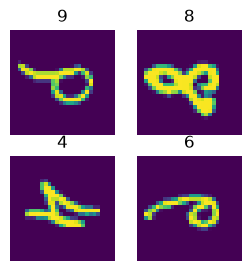

In [38]:
plt.figure(figsize=(3, 3))
i=0
for ds,lb in data_train.take(4):
    print(ds.shape,lb)
    ax = plt.subplot(2, 2, i + 1)
    plt.imshow(ds[0].numpy())
    plt.title('{}'.format(lb[0].numpy()))
    plt.axis("off")
    i+=1

### Método 2 — Capas de preprocesamiento de Keras en el pipeline

Keras ofrece **capas** de aumento (`RandomFlip`, `RandomZoom`, `RandomContrast`, `RandomCrop`, `Rescaling`) que se encadenan con `Sequential`. Aquí se aplican dentro de `map`, igual que el método 1, pero con la API de capas (más legible y reutilizable). `CategoryEncoding` genera el *one-hot* de las etiquetas.

In [39]:
from tensorflow.keras import layers, Sequential
trainAug = Sequential([
        layers.Rescaling(scale=1.0 / 255),
        layers.RandomContrast(0.5),
        layers.RandomZoom(.5, .2),
        layers.RandomFlip("horizontal"),
    ],name='augmentation_in_model')
layer_onehot = layers.CategoryEncoding(
          num_tokens=10, output_mode="one_hot")

In [40]:
def data_load_sequential(data_ds,shuffle_train=True ,batch_=5):
    data_ds = data_ds.map(
        lambda x, y: (trainAug(x, training=shuffle_train), layer_onehot(y))
    )

    if shuffle_train:
        data_ds = data_ds.shuffle(len(data_ds))
    data_ds = data_ds.batch(batch_)
    data_ds = data_ds.prefetch(tf.data.AUTOTUNE)
    return data_ds

data_train = data_load_sequential(ds_train)
data_test = data_load_sequential(ds_test,shuffle_train=False)

(5, 28, 28, 1) tf.Tensor(
[[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]

 [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]], shape=(5, 1, 10), dtype=float32)
(5, 28, 28, 1) tf.Tensor(
[[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]

 [[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]], shape=(5, 1, 10), dtype=float32)
(5, 28, 28, 1) tf.Tensor(
[[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]

 [[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]], shape=(5, 1, 10), dtype=float32)
(5, 28, 28, 1) tf.Tensor(
[[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]

 [[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]

 [[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]], shape=(5, 1, 10), dtype=float32)


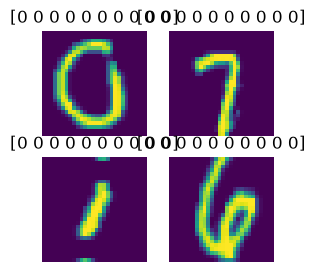

In [41]:
plt.figure(figsize=(3, 3))
i=0
for ds,lb in data_train.take(4):
    print(ds.shape,lb)
    ax = plt.subplot(2, 2, i + 1)
    plt.imshow(ds[0].numpy())
    shaped=ds[0].numpy().shape
    index = tf.argmax(lb, axis=1)
    plt.title('{}'.format(index[0].numpy()))
    plt.axis("off")
    i+=1

### Método 3 — Aumento **dentro del modelo**

Las mismas capas de aumento se colocan como **primeras capas del modelo**. Ventaja: el aumento se ejecuta en GPU junto con el resto de la red y viaja con el modelo al exportarlo. Detalle clave: estas capas de aumento **solo se activan en entrenamiento** y quedan inertes en inferencia, automáticamente.

In [42]:
tf.keras.backend.clear_session()
model = tf.keras.Sequential()
model.add(tf.keras.Input(shape=shaped))
model.add(trainAug)
model.add(layers.Conv2D(16, 3, padding='same', activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(10,activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation_in_model           │ (None, 28, 28, 1)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       125,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,610 (490.66 KB)

 Trainable params: 125,610 (490.66 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
import glob
image_count = len([f for f in glob.glob('../imgs/*/*.*') if f.lower().endswith(('.jpg', '.png','.jpeg'))])
print(image_count)

9


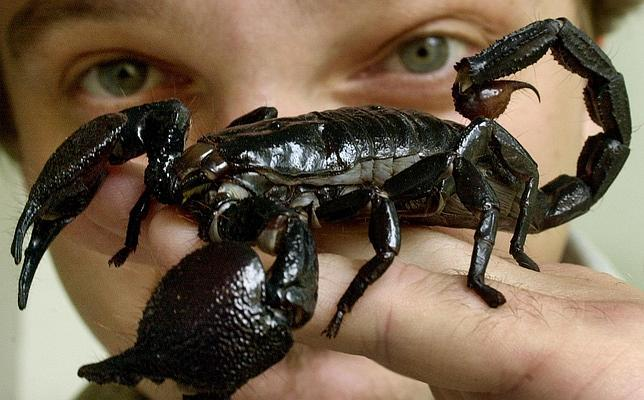

In [44]:
import PIL
import PIL.Image
animls = list(glob.glob('../imgs/animales/*'))
PIL.Image.open(str(animls[0]))

In [45]:
batch_size = 2
img_height = 64
img_width = 64

train_ds = tf.keras.utils.image_dataset_from_directory(
  '../imgs/',
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names
print(class_names)



Found 9 files belonging to 4 classes.
Using 8 files for training.
['animales', 'apto', 'arte', 'ciudad']


In [46]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break


(2, 64, 64, 3)
(2,)


In [47]:
num_classes = 5

data_augmentation = tf.keras.Sequential([
  tf.keras.layers.Rescaling(1./255), # (1./127.5, offset=-1) #si [-1,1]
tf.keras.layers.RandomFlip("horizontal_and_vertical"),
tf.keras.layers.RandomRotation(0.2),
])
data_augmentation.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

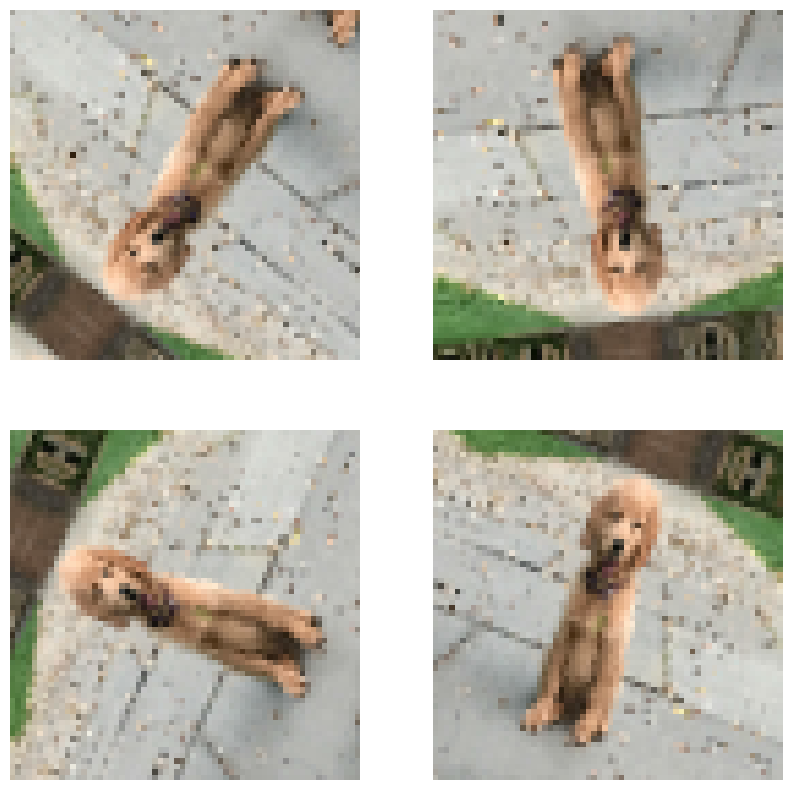

In [48]:
image, label = next(iter(train_ds))
plt.figure(figsize=(10, 10))
for i in range(4):
  augmented_image = data_augmentation(image)
  ax = plt.subplot(2, 2, i + 1)
  plt.imshow(augmented_image[0])
  plt.axis("off")

## Pipeline de texto: IMDB, vectorización y *embeddings*

Cerramos con un pipeline de **texto** sobre el dataset IMDB (reseñas de cine, etiqueta positiva/negativa). El flujo es: cargar → normalizar el texto → **vectorizar** (texto → secuencia de IDs con `TextVectorization`) → **embeddings** (IDs → vectores densos). Los embeddings son el puente hacia las RNN/LSTM del Módulo 7.

In [49]:
train_data, validation_data, test_data = tfds.load(
    name="imdb_reviews", 
    split=('train[:60%]', 'train[60%:]', 'test'),
    as_supervised=True)

In [50]:
train_examples_batch, train_labels_batch = next(iter(train_data.batch(1)))
print(train_examples_batch,train_labels_batch)

tf.Tensor([b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."], shape=(1,), dtype=string) tf.Tensor([0], shape=(1,), dtype=int64)


`TextVectorization` acepta una función de **estandarización** para limpiar el texto antes de tokenizar. Aquí `tf_lower_and_split_punct` normaliza Unicode, pasa a minúsculas, separa la puntuación y añade marcas `[START]`/`[END]`.

In [51]:
def tf_lower_and_split_punct(text):
    text = tf.strings.lower(text)
    text = tf.strings.regex_replace(text, '[^ a-z.?!,¿]', '')
    text = tf.strings.regex_replace(text, '[.?!,¿]', r' \0 ')
    text = tf.strings.strip(text)
    text = tf.strings.join(['[START]', text, '[END]'], separator=' ')
    return text

In [52]:
def data_load_txt(data_ds,shuffle_=True ,batch_=12):
    data_ds = data_ds.cache()
    if shuffle_:
        data_ds = data_ds.shuffle(len(data_ds))
    data_ds = data_ds.batch(batch_)
    data_ds = data_ds.prefetch(tf.data.AUTOTUNE)
    return data_ds

BATCH=32
data_train = data_load_txt(train_data,batch_=BATCH)
data_test = data_load_txt(test_data,shuffle_=False,batch_=BATCH)
data_val = data_load_txt(validation_data,shuffle_=False,batch_=BATCH)

**`TextVectorization`** aprende un vocabulario a partir del texto (`adapt`) y convierte cada reseña en una **secuencia de IDs enteros**. `max_tokens` limita el tamaño del vocabulario a las palabras más frecuentes.

In [53]:
max_vocab_size = 10000

input_text_processor = tf.keras.layers.TextVectorization(
    standardize=tf_lower_and_split_punct,
    max_tokens=max_vocab_size)

`adapt` recorre el texto de entrenamiento y **construye el vocabulario**. Es análogo a "entrenar" el tokenizador: hay que hacerlo solo con datos de entrenamiento.

In [54]:
reviews_only_ds = data_train.map(lambda a, b: a) 
input_text_processor.adapt(reviews_only_ds)

In [55]:
input_text_processor.get_vocabulary()[:10]

['',
 '[UNK]',
 np.str_('the'),
 np.str_('.'),
 np.str_(','),
 np.str_('and'),
 np.str_('a'),
 np.str_('of'),
 np.str_('to'),
 np.str_('is')]

In [56]:
for idx in data_train.take(1):
    example_tokens = input_text_processor(idx[0])
    print(idx[1],example_tokens)

tf.Tensor([0 1 1 1 1 0 0 0 1 1 1 1 0 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 0 0 0 1], shape=(32,), dtype=int64) tf.Tensor(
[[  34  433  528 ...    0    0    0]
 [  34    2   92 ...    0    0    0]
 [  34    1    4 ... 8107    3   35]
 ...
 [  34 5308   13 ...    0    0    0]
 [  34  671    4 ...    0    0    0]
 [  34   13  235 ...    0    0    0]], shape=(32, 1093), dtype=int64)


In [57]:
input_vocab = np.array(input_text_processor.get_vocabulary())
tokens = input_vocab[example_tokens[0].numpy()]
' '.join(tokens)

'[START] problem child is one of the [UNK] movies ever made . its not the worst though some people will disagree with me on that , but its not the best either . its about a [UNK] yearold boy who [UNK] comic havoc on a [UNK] couple john ritter , amy [UNK] who [UNK] [UNK] him . this film is too silly and unbelievable because i dont buy for one second that a child could act as [UNK] as the kid does in this film . its [UNK] and preposterous although i did laugh several times throughout i really dont know why . but i cant recommend this film . i know im being too kind to it . if there is one positive thing about problem child is that its better than the sequel which was just awful . br br out of four [END]                                                                                                                                                                                                                                                                                                  

Text(0.5, 1.0, 'Mask')

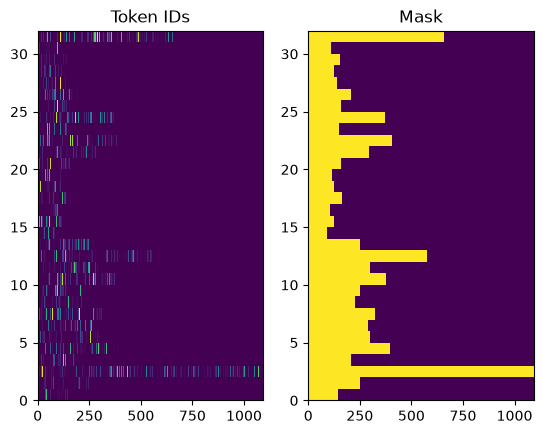

In [58]:
plt.subplot(1, 2, 1)
plt.pcolormesh(example_tokens)
plt.title('Token IDs')

plt.subplot(1, 2, 2)
plt.pcolormesh(example_tokens != 0)
plt.title('Mask')

Finalmente, una capa **`Embedding`** convierte cada ID de palabra en un **vector denso** entrenable de dimensión fija. Encadenar `TextVectorization → Embedding` dentro de un `Sequential` deja el modelo listo para recibir texto crudo. Los embeddings son la base del procesamiento de secuencias que veremos en el Módulo 7.

In [59]:
from tensorflow.keras.layers import Embedding,Dense
from tensorflow.keras import Sequential

vocab_size = 10000
embedding_dim=16

model = Sequential([
input_text_processor,
  Embedding(input_dim = vocab_size, 
            output_dim = embedding_dim, 
            name="embedding"),
   Dense(1)])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (32, None)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)